<a href="https://colab.research.google.com/github/vivaanjain-1/Medlytics_2026/blob/main/SVM_Exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVM Exercises

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn import metrics

Load Pima diabetes dataset

In [2]:
url = "https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week1/diabetes.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

# YOUR CODE HERE
data = pd.read_csv(url, names=names)
invalid = ['plas', 'pres', 'skin', 'test', 'mass']
for i in invalid:
    data[i].replace(to_replace=0, value=np.nan, inplace=True)
data = data.dropna(axis=0).reset_index(drop=True)
data.head()

/tmp/ipykernel_690/1275829753.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[i].replace(to_replace=0, value=np.nan, inplace=True)


,preg,plas,pres,skin,test,mass,pedi,age,class
0,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
1,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
2,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
3,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
4,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1


Split data into training, colidation, and test sets with a test size of 25%

In [3]:
# YOUR CODE HERE
X_cols = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']
y_col = 'class'

test_size = 0.25

X_train, X_test, y_train, y_test = train_test_split(
    data[X_cols], data[y_col], test_size=test_size, random_state=0)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=test_size, random_state=0)

print('There are {} training samples with {} features and {} associated classification labels'.format(*X_train.shape, *y_train.shape))
print('There are {} validation samples with {} features and {} associated classification labels'.format(*X_val.shape, *y_val.shape))
print('There are {} test samples with {} features and {} associated classification labels'.format(*X_test.shape, *y_test.shape))

There are 220 training samples with 8 features and 220 associated classification labels
There are 74 validation samples with 8 features and 74 associated classification labels
There are 98 test samples with 8 features and 98 associated classification labels


Create a model with sklearn's SVC and a high gamma value (perhaps 1.0)

In [5]:
# YOUR CODE HERE
model = SVC(gamma=1.0)
model.fit(X_train, y_train)

SVC(gamma=1.0)

Print accuracy of training and validation data

In [7]:
# YOUR CODE HERE
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

Training Accuracy: 1.0
Validation Accuracy: 0.6756756756756757


Create a model with sklearn's SVC and a low gamma value (perhaps .001)

In [8]:
# YOUR CODE HERE
model = SVC(gamma=0.001)
model.fit(X_train, y_train)

SVC(gamma=0.001)

Print accuracy of training and validation data

In [9]:
# YOUR CODE HERE
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

Training Accuracy: 0.8727272727272727
Validation Accuracy: 0.7432432432432432


Explain the accuracy results below.

High gamma (1.0) makes the model fit the training data too closely. It gets every single training point right (accuracy 1.0), but does badly on new data it hasn't seen (validation accuracy only 0.676). It basically memorized the training answers instead of learning the real pattern, so it doesn't work well on anything new.
Low gamma (0.001) doesn't get the training data perfectly (0.873), but it does better on validation data (0.743). It's a simpler model that actually generalizes to new patients instead of just memorizing old ones.
So low gamma is the better choice here, since what matters most is how well the model does on data it hasn't seen before, not how well it memorizes what it already saw.

Print the confusion matrices for your high and low gamma models (both numeric and visualized)

High gamma confusion matrix:
 [[50  0]
 [24  0]]
Low gamma confusion matrix:
 [[48  2]
 [17  7]]


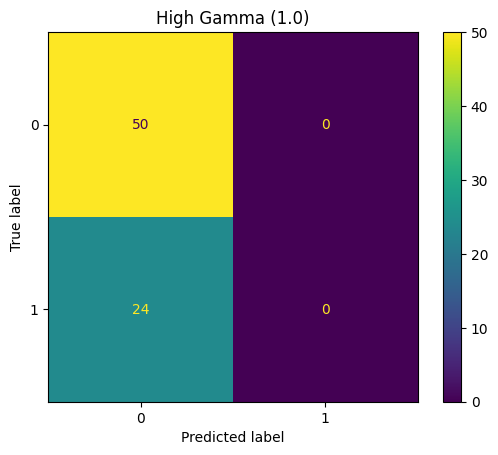

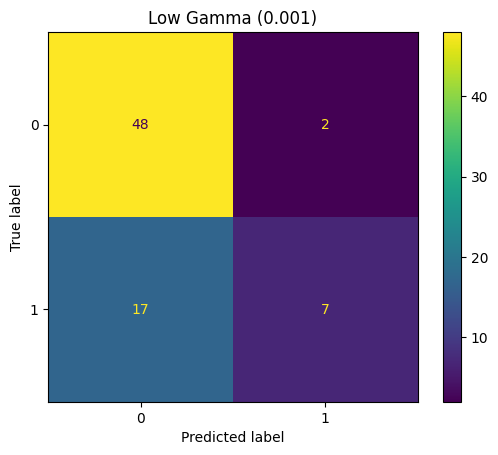

In [10]:
# YOUR CODE HERE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model_high = SVC(gamma=1.0)
model_high.fit(X_train, y_train)
cm_high = confusion_matrix(y_val, model_high.predict(X_val))

model_low = SVC(gamma=0.001)
model_low.fit(X_train, y_train)
cm_low = confusion_matrix(y_val, model_low.predict(X_val))

print("High gamma confusion matrix:\n", cm_high)
print("Low gamma confusion matrix:\n", cm_low)

ConfusionMatrixDisplay(cm_high).plot()
plt.title("High Gamma (1.0)")
plt.show()

ConfusionMatrixDisplay(cm_low).plot()
plt.title("Low Gamma (0.001)")
plt.show()